In [65]:
import pandas as pd
from datetime import date, timedelta

import random
import geopandas as gpd
import numpy as np

import sys

sys.path.insert(0, "../Modules")

from preprocessing_utils import *

enc = 'utf-8'
random.seed(0)

In [66]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'
NUTS2_LOWER = 'veneto'

In [67]:
## Reading shapefiles from Italy
folder_path = "C:/Users/dimit/Documents/noa hoard/Italy Shapefiles"

italy_gdf = gpd.read_file(f"{folder_path}\italy.shp")
rivers_gdf = gpd.read_file(f"{folder_path}\waterways.shp")

<AxesSubplot:>

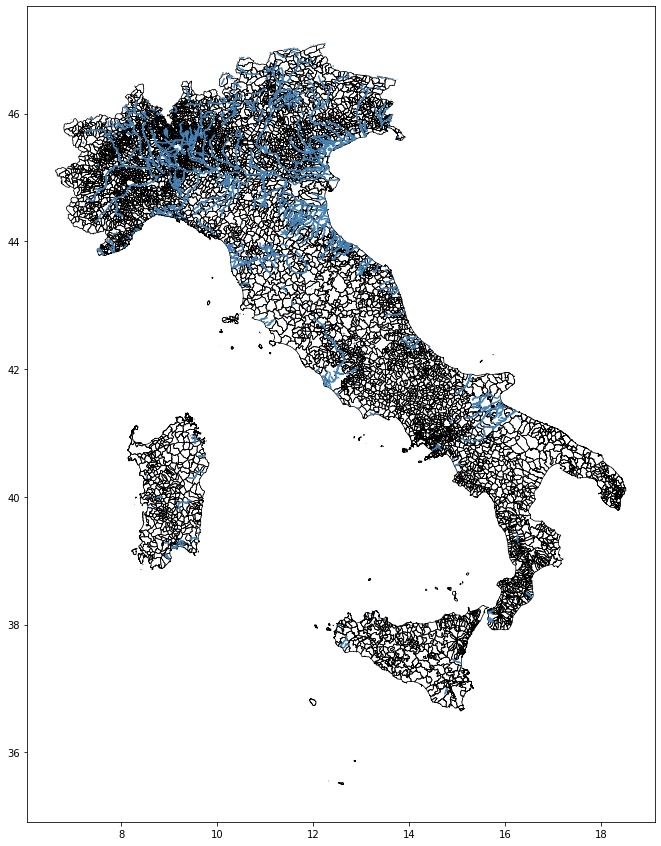

In [68]:
ax = rivers_gdf.plot(markersize=.1, figsize=(15, 15), cmap='jet', color='steelblue')
italy_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.7)

In [69]:
italy_gdf.head(5)

,FID,COD_RIP,COD_REG,COD_PROV,COD_CM,COD_UTS,PRO_COM,PRO_COM_T,COMUNE,COMUNE_A,CC_UTS,SHAPE_LENG,GlobalID,SHAPE_Le_1,SHAPE_Area,geometry
0,1,1,1,1,201,201,1042,001042,Burolo,None,0,13222.896787,{428A5371-1203-4014-9D3B-D6F2353A226F},0.141254,5.475974e+06,"POLYGON ((7.93812 45.49086, 7.93818 45.49034, ..."
1,2,1,1,1,201,201,1060,001060,Casalborgone,None,0,24056.822202,{7772511B-1529-4A71-8ED1-7880DC64354A},0.270078,2.012501e+07,"POLYGON ((7.91362 45.15298, 7.91369 45.15297, ..."
2,3,1,1,1,201,201,1076,001076,Chianocco,None,0,21411.076163,{0F2EE4C5-219C-43DD-AD6E-D8AE5E9F5F7B},0.225795,1.861335e+07,"POLYGON ((7.18303 45.19351, 7.18342 45.19309, ..."
3,4,1,1,1,201,201,1077,001077,Chiaverano,None,0,18164.369945,{16E8325A-C7CD-4B85-AB7D-74216B9D06B3},0.196687,1.202212e+07,"POLYGON ((7.90330 45.52628, 7.90360 45.52626, ..."
4,5,1,1,1,201,201,1079,001079,Chiesanuova,None,0,10777.398475,{8FF28D8A-C5F5-4214-AFA0-999D470CF9C8},0.116011,4.118911e+06,"POLYGON ((7.65285 45.42981, 7.65407 45.42951, ..."


In [70]:
nuts2_gdf = italy_gdf.loc[italy_gdf['COD_REG'] == 5].copy()
nuts2_gdf.head()

,FID,COD_RIP,COD_REG,COD_PROV,COD_CM,COD_UTS,PRO_COM,PRO_COM_T,COMUNE,COMUNE_A,CC_UTS,SHAPE_LENG,GlobalID,SHAPE_Le_1,SHAPE_Area,geometry
114,115,2,5,24,0,24,24070,024070,Mussolente,None,0,21396.915642,{F056368A-60F4-4355-8392-18A40FA049CD},0.229581,1.543081e+07,"POLYGON ((11.79414 45.79929, 11.79464 45.79910..."
115,116,2,5,24,0,24,24035,024035,Costabissara,None,0,19751.461429,{56C62B6B-0532-4D4F-9198-B37BEBC92AB6},0.218976,1.313203e+07,"POLYGON ((11.48958 45.60955, 11.48971 45.60951..."
121,122,2,5,23,0,23,23001,023001,Affi,None,0,16409.933361,{2C8E0DB3-E06F-4162-B4AA-C0A51D9F6FCB},0.181871,9.881361e+06,"POLYGON ((10.78164 45.57539, 10.78274 45.57519..."
122,123,2,5,23,0,23,23002,023002,Albaredo d'Adige,None,0,27907.866591,{ADE3DB5E-240F-4D44-893D-656EC25230D4},0.310924,2.825321e+07,"POLYGON ((11.28596 45.33269, 11.28734 45.33242..."
123,124,2,5,23,0,23,23003,023003,Angiari,None,0,18600.917222,{AAC2D671-079A-46E7-84B0-24C7E4A99F5C},0.201585,1.347062e+07,"POLYGON ((11.26925 45.24528, 11.27031 45.24443..."


<AxesSubplot:>

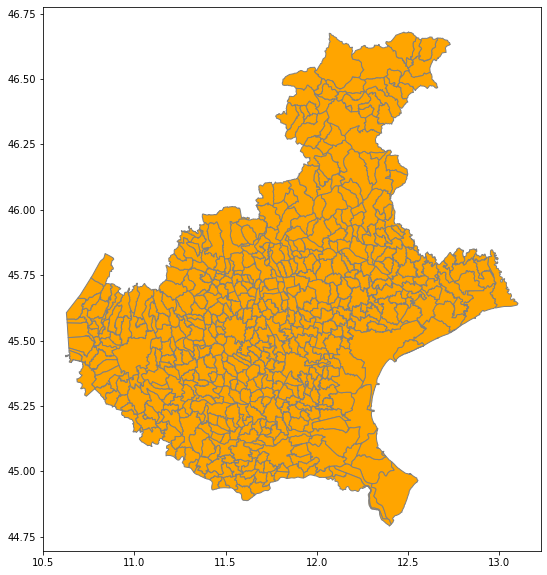

In [71]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [72]:
nuts2_gdf.drop(columns=['FID', 'COD_RIP', 'COD_REG', 'COD_PROV', 'COD_CM', 'COD_UTS', 'PRO_COM', 'PRO_COM_T', 'COMUNE_A', 'CC_UTS' ,'SHAPE_LENG', 'GlobalID', 'SHAPE_Le_1'], inplace = True)
nuts2_gdf.rename(columns={"COMUNE": "lau1", "SHAPE_Area" : "area"}, inplace = True)
process_italic(nuts2_gdf, 'lau1')

In [73]:
nuts2_gdf.head(5)

,lau1,area,geometry
114,mussolente,1.543081e+07,"POLYGON ((11.79414 45.79929, 11.79464 45.79910..."
115,costabissara,1.313203e+07,"POLYGON ((11.48958 45.60955, 11.48971 45.60951..."
121,affi,9.881361e+06,"POLYGON ((10.78164 45.57539, 10.78274 45.57519..."
122,albaredo da adige,2.825321e+07,"POLYGON ((11.28596 45.33269, 11.28734 45.33242..."
123,angiari,1.347062e+07,"POLYGON ((11.26925 45.24528, 11.27031 45.24443..."


In [74]:
indexes = []

nuts2 = nuts2_gdf

for index, row in rivers_gdf.iterrows():
    for index2, row2 in nuts2.iterrows():
                    
        if row['geometry'].intersects(row2['geometry']):
                indexes.append(index)

nuts2_rivers_gdf = rivers_gdf.loc[indexes].reset_index(drop=True)

In [75]:
nuts2_rivers_gdf.head()

,osm_id,name,type,width,geometry
0,4478117,Rio Nuovo,canal,8,"LINESTRING (12.32009 45.43708, 12.32009 45.437..."
1,4478118,None,canal,8,"LINESTRING (12.32019 45.43641, 12.32092 45.436..."
2,4478168,Rio de San Trovaso,canal,10,"LINESTRING (12.32563 45.42955, 12.32592 45.430..."
3,4478935,RIO DE S. MARGHERITA,canal,8,"LINESTRING (12.32317 45.43541, 12.32310 45.434..."
4,4479144,None,canal,8,"LINESTRING (12.33380 45.42536, 12.33335 45.42315)"


<AxesSubplot:>

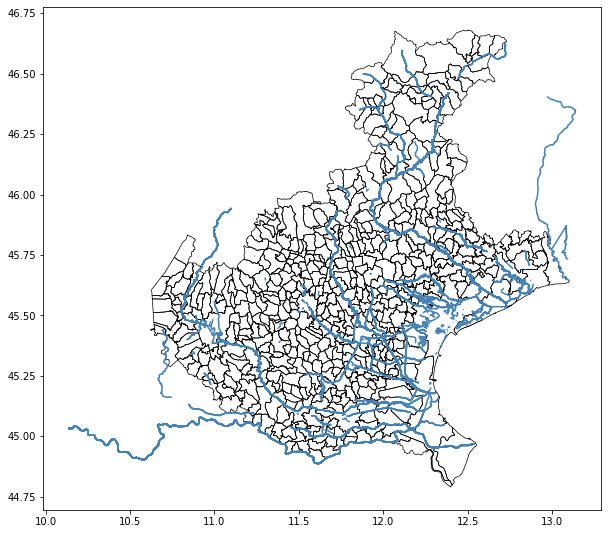

In [76]:
ax = nuts2_rivers_gdf.plot(markersize=.1, figsize=(10, 10), cmap='jet', color='steelblue')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.7)

In [77]:
lau1_units = nuts2_gdf['lau1'].unique().tolist()

with open(f'data/{NUTS0}_SHP_{NUTS2}_lau1_processed.txt', 'w', encoding=enc) as f:
    for item in lau1_units:
        f.write("%s\n" % item)

print(f"Number of LAU1 Units in {NUTS2} (from shapefile): {len(lau1_units)}")

Number of LAU1 Units in Veneto (from shapefile): 571


In [78]:
nuts2_gdf.reset_index(inplace=True, drop = True)
nuts2_rivers_gdf.reset_index(inplace=True, drop=True)

In [79]:
df_grid = create_grid(nuts2_rivers_gdf, nuts2_gdf, col_municipal='lau1', dimension=2)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

e:\Google Drive\NOA\MBD-Prediction\Italy\../Modules\preprocessing_utils.py:37: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\dtypes\cast.py:118: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0

In [80]:
df_grid.rename(columns={"NAME": "lau1"}, inplace = True)

<AxesSubplot:>

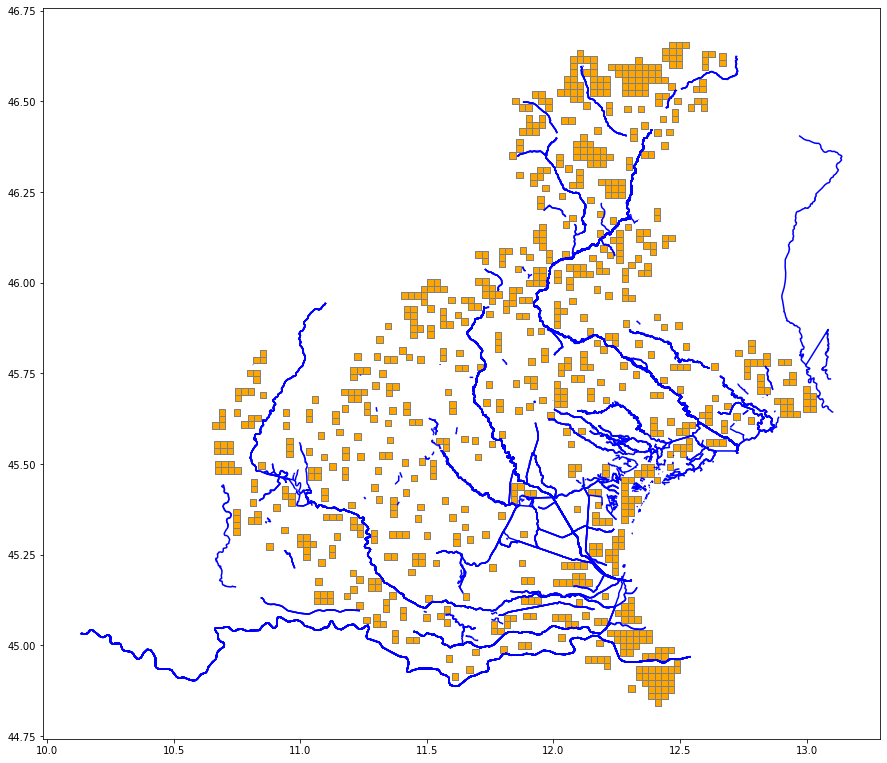

In [81]:
ax = nuts2_rivers_gdf.plot(markersize=.1, figsize=(15, 15), cmap='jet', color='blue')
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [82]:
grid_lau1 = df_grid['lau1'].unique().tolist()
print(f"Number of LAU1 Units in Grid: {len(grid_lau1)}")

Number of LAU1 Units in Grid: 256


['mussolente', 'costabissara', 'affi', 'angiari', 'arcole', 'creazzo', 'sanguinetto', 'saint mauro da saline', 'soave', 'saint gregorio nelle alpi', 'quinto da treviso', 'refrontolo', 'cibiana da cadore', 'sossano', 'sovizzo', 'saint nicolo da comelico', 'meduna da livenza', 'monastier da treviso', 'colle saint lucia', 'carbonera', 'portobuffole', 'arqua petrarca', 'crespano da grappa', 'crocetta da montello', 'moriago da battaglia', 'rotzo', 'salcedo', 'monfumo', 'curtarolo', 'este', 'massanzago', 'ceregnano', 'corbola', 'stienta', 'cervarese saint croce', 'rubano', 'teglio veneto', 'morgano', 'solagna', 'villanova da camposampiero', 'due carrare', 'arqua polesine', 'costermano sul garda', 'romano da ezzelino', 'saint tomaso agordino', 'giavera da montello', 'cordignano', 'zermeghedo', 'zovencedo', 'zugliano', 'follina', 'stra', 'pincara', 'polesella', 'pontecchio polesine', 'bosaro', 'calto', 'sorga', 'palu', 'nanto', 'laghi', 'lastebasse', 'mason vicentino', 'molvena', 'montebello v

C:\Users\dimit\AppData\Local\Temp/ipykernel_12584/839959091.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lost_lau1["centroid"] = lost_lau1["geometry"].centroid
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\geodataframe.py:1472: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


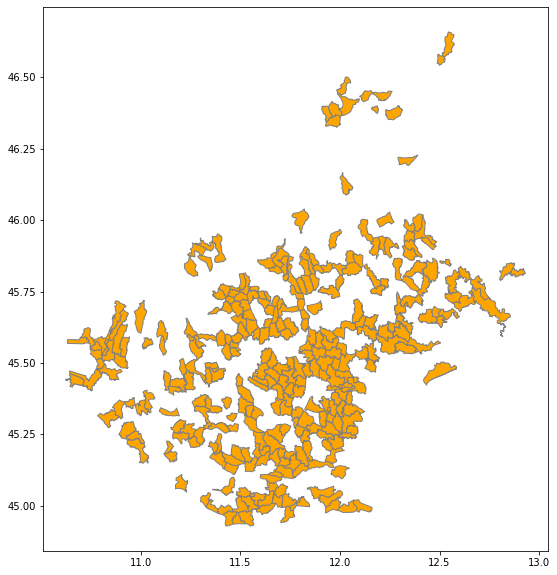

In [83]:
if (len(lau1_units) != len(grid_lau1)):
    delta = [item for item in lau1_units if item not in grid_lau1]
    print(delta)

    lost_lau1 = nuts2_gdf[nuts2_gdf['lau1'].isin(delta)]
    lost_lau1["centroid"] = lost_lau1["geometry"].centroid

    add_to_nuts2_grid = pd.DataFrame()
    add_to_nuts2_grid['lau1'] = lost_lau1['lau1']
    add_to_nuts2_grid['geometry'] = lost_lau1['geometry']
    add_to_nuts2_grid['x'] = round(lost_lau1['centroid'].x, 5)
    add_to_nuts2_grid['y'] = round(lost_lau1['centroid'].y, 5)

    lost_lau1.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [84]:
nuts2_grid = df_grid.drop(columns=['centers'])

In [85]:
nuts2_grid

,geometry,lau1,x,y
0,"POLYGON ((11.30532 45.28321, 11.30532 45.30117...",albaredo da adige,11.29256,45.29219
1,"POLYGON ((11.30532 45.30117, 11.30532 45.31914...",albaredo da adige,11.29256,45.31016
2,"POLYGON ((11.18963 45.64455, 11.18963 45.66252...",crespadoro,11.17678,45.65353
3,"POLYGON ((11.10822 45.39683, 11.10822 45.41480...",saint martino buon albergo,11.09543,45.40581
4,"POLYGON ((11.10822 45.41480, 11.10822 45.43276...",saint martino buon albergo,11.09543,45.42378
...,...,...,...,...
828,"POLYGON ((12.20913 46.31936, 12.20913 46.33732...",val da zoldo,12.19613,46.32834
829,"POLYGON ((12.20913 46.33732, 12.20913 46.35529...",val da zoldo,12.19613,46.34631
830,"POLYGON ((12.20913 46.35529, 12.20913 46.37326...",val da zoldo,12.19613,46.36427
831,"POLYGON ((12.23512 46.33732, 12.23512 46.35529...",val da zoldo,12.22213,46.34631


In [86]:
if (len(lau1_units) != len(grid_lau1)):
    nuts2_grid = pd.concat([nuts2_grid, add_to_nuts2_grid], axis=0)

nuts2_grid.reset_index(inplace=True, drop=True)

In [87]:
nuts2_grid['nuts2'] = NUTS2_LOWER

In [88]:
nuts2_grid.rename(columns={"geometry": "shape"}, inplace=True)

In [89]:
nuts2_grid

,shape,lau1,x,y,nuts2
0,"POLYGON ((11.30532 45.28321, 11.30532 45.30117...",albaredo da adige,11.29256,45.29219,veneto
1,"POLYGON ((11.30532 45.30117, 11.30532 45.31914...",albaredo da adige,11.29256,45.31016,veneto
2,"POLYGON ((11.18963 45.64455, 11.18963 45.66252...",crespadoro,11.17678,45.65353,veneto
3,"POLYGON ((11.10822 45.39683, 11.10822 45.41480...",saint martino buon albergo,11.09543,45.40581,veneto
4,"POLYGON ((11.10822 45.41480, 11.10822 45.43276...",saint martino buon albergo,11.09543,45.42378,veneto
...,...,...,...,...,...
1143,"POLYGON ((11.18983 45.41439, 11.18975 45.41388...",caldiero,11.16921,45.40643,veneto
1144,"POLYGON ((11.53260 45.31257, 11.53225 45.31189...",noventa vicentina,11.55886,45.28529,veneto
1145,"POLYGON ((11.19826 45.25346, 11.19861 45.25216...",saint pietro da morubio,11.20096,45.24276,veneto
1146,"POLYGON ((11.75146 45.87320, 11.75260 45.87308...",pove da grappa,11.73823,45.83013,veneto


In [90]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

In [91]:
nuts2_grid_points

,shape,lau1,x,y,nuts2,geometry
0,"POLYGON ((11.30532 45.28321, 11.30532 45.30117...",albaredo da adige,11.29256,45.29219,veneto,POINT (11.29256 45.29219)
1,"POLYGON ((11.30532 45.30117, 11.30532 45.31914...",albaredo da adige,11.29256,45.31016,veneto,POINT (11.29256 45.31016)
2,"POLYGON ((11.18963 45.64455, 11.18963 45.66252...",crespadoro,11.17678,45.65353,veneto,POINT (11.17678 45.65353)
3,"POLYGON ((11.10822 45.39683, 11.10822 45.41480...",saint martino buon albergo,11.09543,45.40581,veneto,POINT (11.09543 45.40581)
4,"POLYGON ((11.10822 45.41480, 11.10822 45.43276...",saint martino buon albergo,11.09543,45.42378,veneto,POINT (11.09543 45.42378)
...,...,...,...,...,...,...
1143,"POLYGON ((11.18983 45.41439, 11.18975 45.41388...",caldiero,11.16921,45.40643,veneto,POINT (11.16921 45.40643)
1144,"POLYGON ((11.53260 45.31257, 11.53225 45.31189...",noventa vicentina,11.55886,45.28529,veneto,POINT (11.55886 45.28529)
1145,"POLYGON ((11.19826 45.25346, 11.19861 45.25216...",saint pietro da morubio,11.20096,45.24276,veneto,POINT (11.20096 45.24276)
1146,"POLYGON ((11.75146 45.87320, 11.75260 45.87308...",pove da grappa,11.73823,45.83013,veneto,POINT (11.73823 45.83013)


<AxesSubplot:>

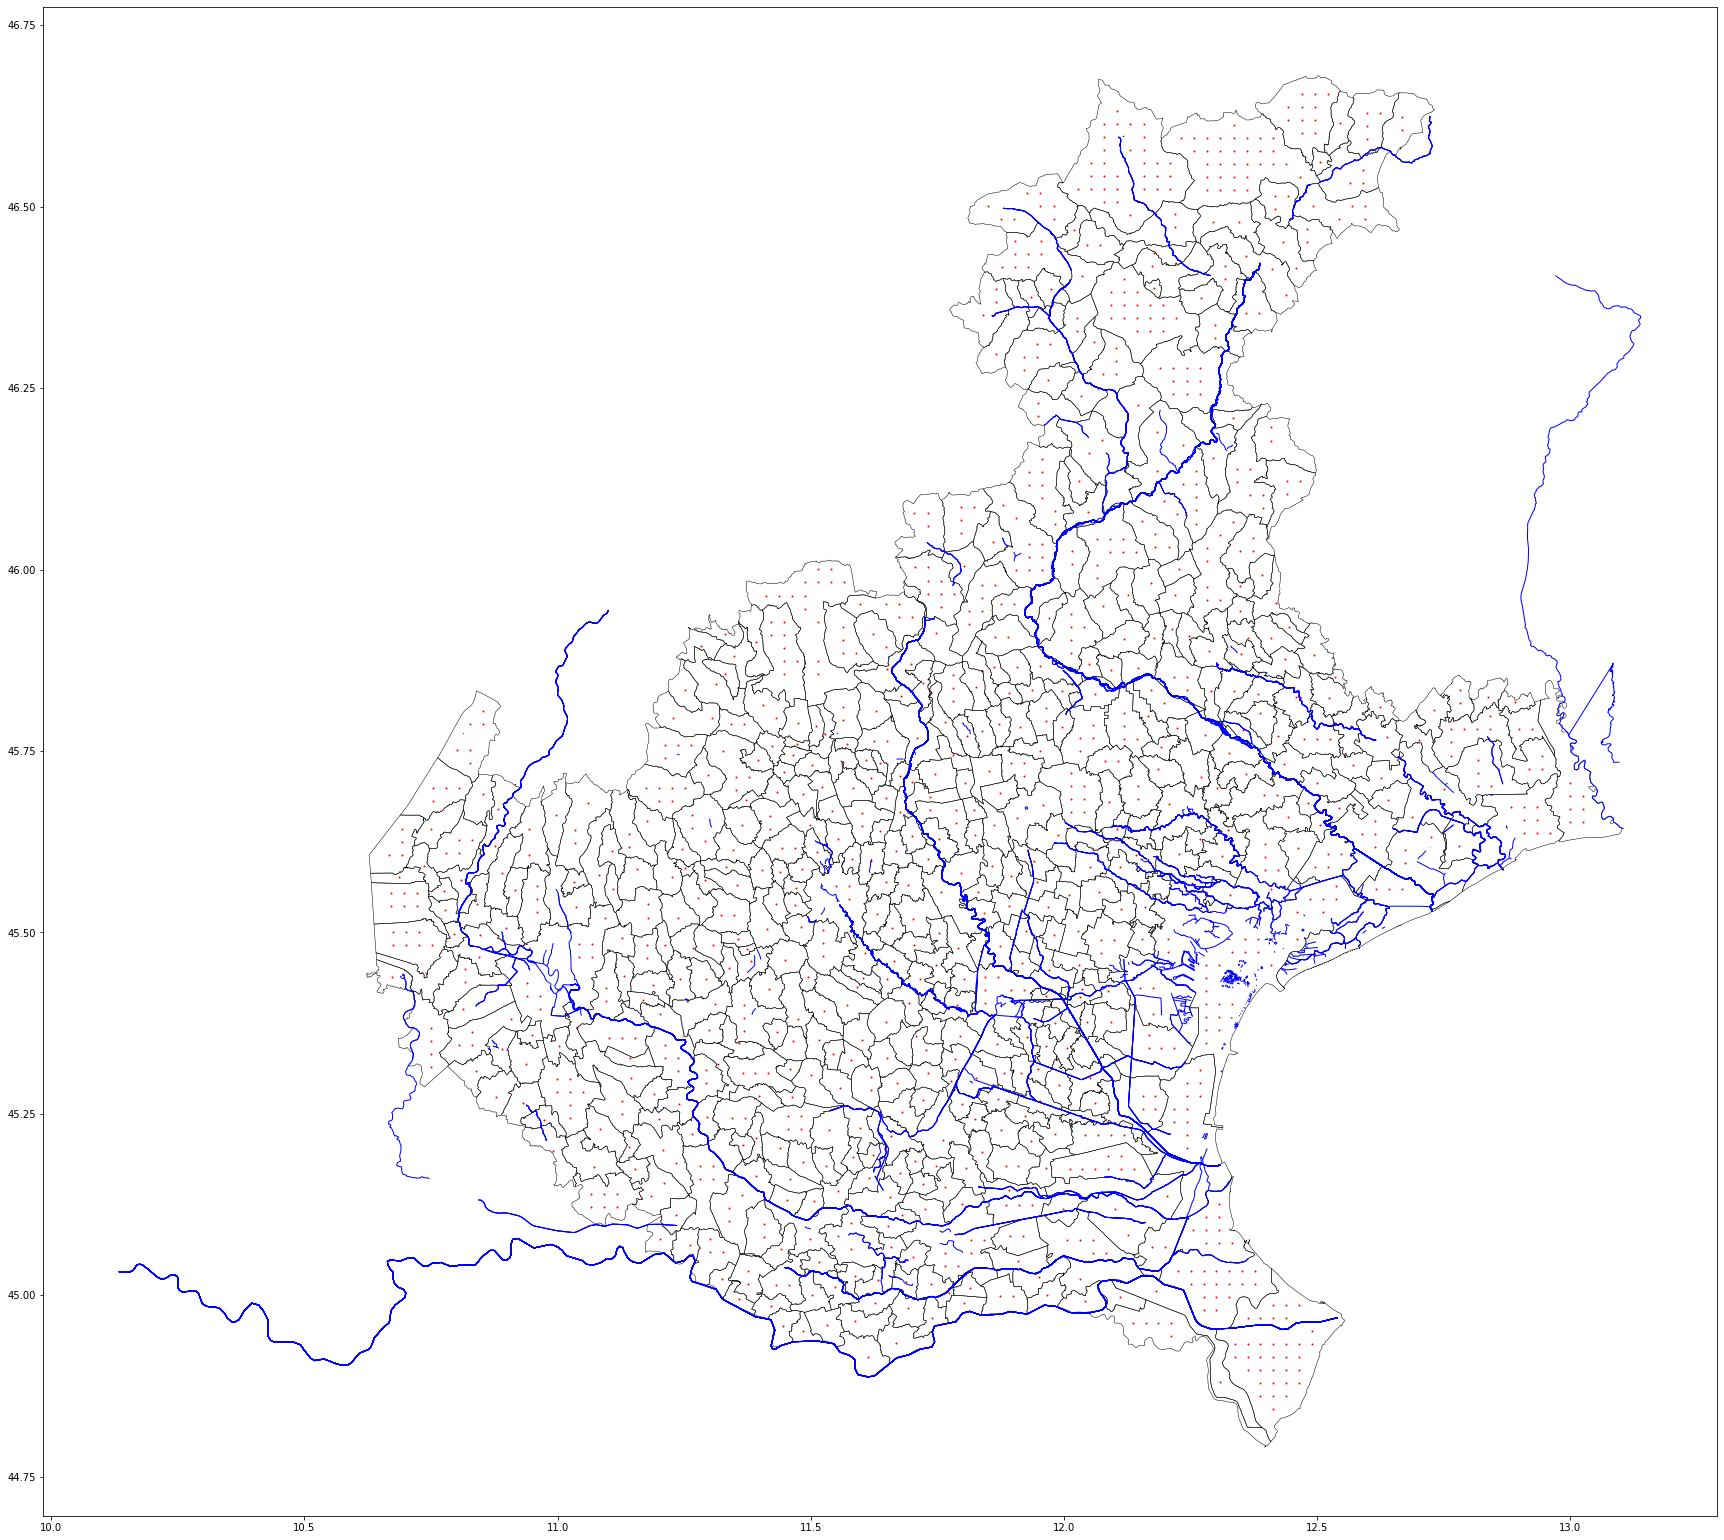

In [92]:
ax = nuts2_grid_points.plot(markersize=1, figsize=(30, 30), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.5)
nuts2_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=1)

In [93]:
value_counts = nuts2_grid['lau1'].value_counts().sort_values()

In [94]:
arr = value_counts.values

In [95]:
arr_norm = np.ceil((15*(arr - np.min(arr) + 1 )/np.ptp(arr))).astype(int)

In [96]:
value_counts_target = pd.Series(data=arr_norm, index=value_counts.index)

In [97]:
value_counts_target

bolzano vicentino          1
asolo                      1
saint giorgio in bosco     1
ferrara da monte baldo     1
nogara                     1
                          ..
val da zoldo               9
venezia                   13
cortina da ampezzo        15
auronzo da cadore         15
porto tolle               16
Length: 571, dtype: int32

In [98]:
idx = []
points = [] 

for index, value in value_counts_target.iteritems():
    if value == value_counts[index]:
        pass
    else: 
        idx.append(index)
        points.append(value_counts[index] - value)
        print(f'Index: {index} || Value: {value_counts[index]} || Target Value: {value}')

Index: arzignano || Value: 2 || Target Value: 1
Index: castagnaro || Value: 2 || Target Value: 1
Index: cogollo da cengio || Value: 2 || Target Value: 1
Index: saint anna da alfaedo || Value: 2 || Target Value: 1
Index: illasi || Value: 2 || Target Value: 1
Index: lusiana || Value: 2 || Target Value: 1
Index: minerbe || Value: 2 || Target Value: 1
Index: isola vicentina || Value: 2 || Target Value: 1
Index: selva da progno || Value: 2 || Target Value: 1
Index: casaleone || Value: 2 || Target Value: 1
Index: foza || Value: 2 || Target Value: 1
Index: perarolo da cadore || Value: 2 || Target Value: 1
Index: tregnago || Value: 2 || Target Value: 1
Index: malo || Value: 2 || Target Value: 1
Index: valle da cadore || Value: 2 || Target Value: 1
Index: crespino || Value: 2 || Target Value: 1
Index: bagnoli da sopra || Value: 2 || Target Value: 1
Index: saint biagio da callalta || Value: 2 || Target Value: 1
Index: selva da cadore || Value: 2 || Target Value: 1
Index: ospitale da cadore || Va

In [99]:
to_remove = pd.Series(data=points, index=idx)

In [100]:
to_remove

arzignano                 1
castagnaro                1
cogollo da cengio         1
saint anna da alfaedo     1
illasi                    1
                         ..
val da zoldo              9
venezia                  14
cortina da ampezzo       16
auronzo da cadore        17
porto tolle              18
Length: 148, dtype: int64

In [101]:
indicies_to_remove = []

for municipality, points in to_remove.iteritems():
    indicies = nuts2_grid.loc[nuts2_grid['lau1'] ==  municipality].index.tolist()
    to_removed = random.sample(indicies, points)
    for item in to_removed:
        indicies_to_remove.append(item)

nuts2_grid.drop(index = indicies_to_remove, axis = 1, inplace = True)
nuts2_grid.reset_index(inplace = True, drop = True)

In [102]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

<AxesSubplot:>

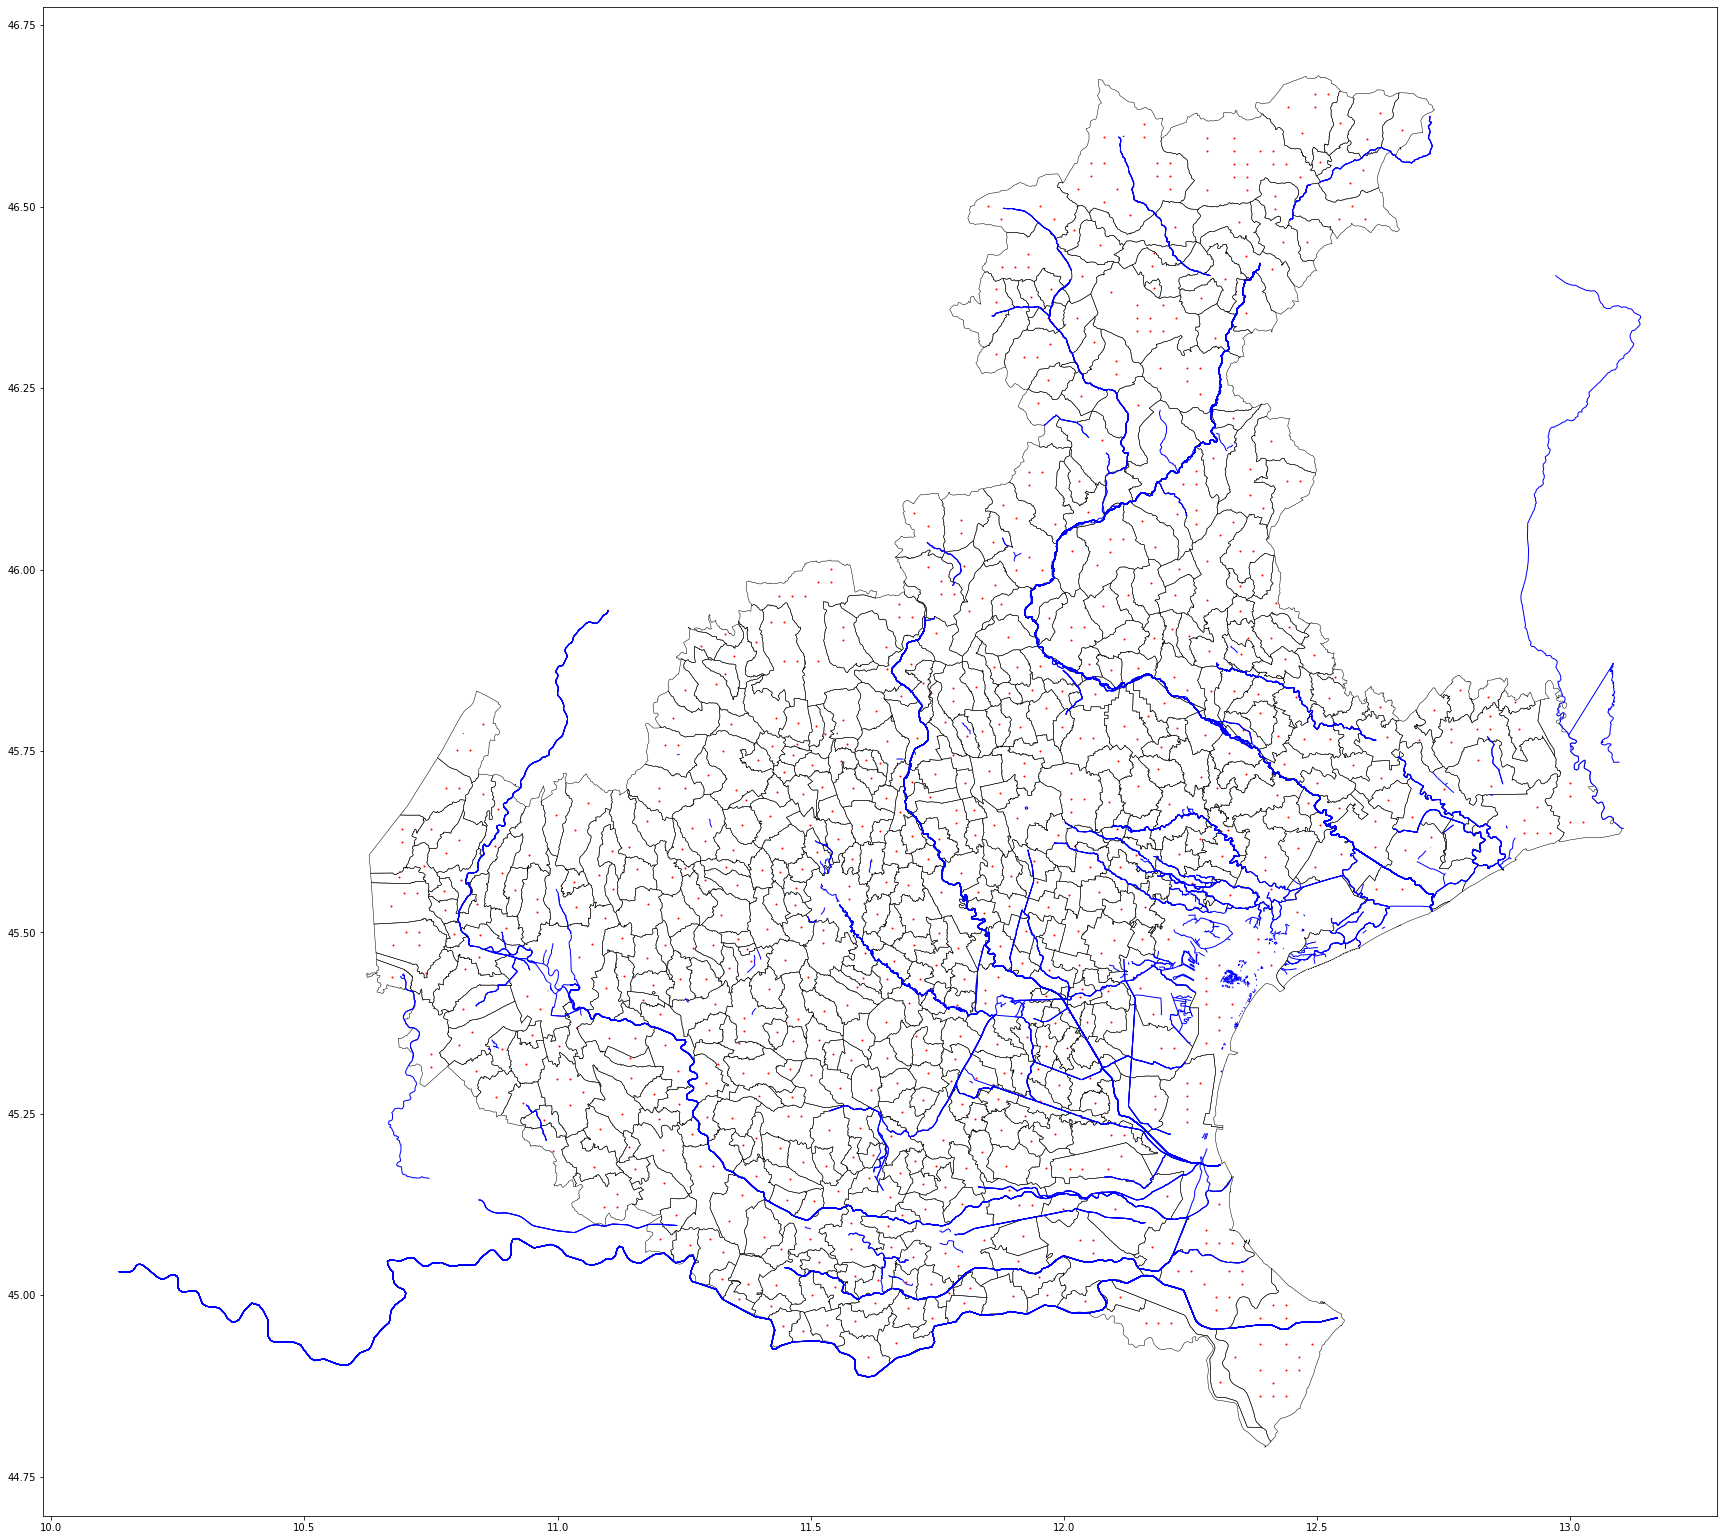

In [103]:
ax = nuts2_grid_points.plot(markersize=1, figsize=(30, 30), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.5)
nuts2_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=1)

In [104]:
len(nuts2_grid['lau1'].unique())

571

In [105]:
nuts2_grid

,shape,lau1,x,y,nuts2,geometry
0,"POLYGON ((11.30532 45.28321, 11.30532 45.30117...",albaredo da adige,11.29256,45.29219,veneto,POINT (11.29256 45.29219)
1,"POLYGON ((11.18963 45.64455, 11.18963 45.66252...",crespadoro,11.17678,45.65353,veneto,POINT (11.17678 45.65353)
2,"POLYGON ((11.10822 45.41480, 11.10822 45.43276...",saint martino buon albergo,11.09543,45.42378,veneto,POINT (11.09543 45.42378)
3,"POLYGON ((10.82646 45.38547, 10.82646 45.40344...",sommacampagna,10.81367,45.39446,veneto,POINT (10.81367 45.39446)
4,"POLYGON ((11.27759 45.63438, 11.27759 45.65234...",valdagno,11.26475,45.64336,veneto,POINT (11.26475 45.64336)
...,...,...,...,...,...,...
799,"POLYGON ((11.18983 45.41439, 11.18975 45.41388...",caldiero,11.16921,45.40643,veneto,POINT (11.16921 45.40643)
800,"POLYGON ((11.53260 45.31257, 11.53225 45.31189...",noventa vicentina,11.55886,45.28529,veneto,POINT (11.55886 45.28529)
801,"POLYGON ((11.19826 45.25346, 11.19861 45.25216...",saint pietro da morubio,11.20096,45.24276,veneto,POINT (11.20096 45.24276)
802,"POLYGON ((11.75146 45.87320, 11.75260 45.87308...",pove da grappa,11.73823,45.83013,veneto,POINT (11.73823 45.83013)


In [106]:
## start and end date is defined from available epidemiological file

In [107]:
start = start_dt = date(2008, 1, 1)
end = end_dt = date(2019, 12, 31)
delta = timedelta(days=1)

In [108]:
dates = []

while start_dt <= end_dt:
    dates.append(start_dt.isoformat())
    start_dt += delta

In [109]:
print('Dates between', start, 'and', end)
print(dates)

Dates between 2008-01-01 and 2019-12-31
['2008-01-01', '2008-01-02', '2008-01-03', '2008-01-04', '2008-01-05', '2008-01-06', '2008-01-07', '2008-01-08', '2008-01-09', '2008-01-10', '2008-01-11', '2008-01-12', '2008-01-13', '2008-01-14', '2008-01-15', '2008-01-16', '2008-01-17', '2008-01-18', '2008-01-19', '2008-01-20', '2008-01-21', '2008-01-22', '2008-01-23', '2008-01-24', '2008-01-25', '2008-01-26', '2008-01-27', '2008-01-28', '2008-01-29', '2008-01-30', '2008-01-31', '2008-02-01', '2008-02-02', '2008-02-03', '2008-02-04', '2008-02-05', '2008-02-06', '2008-02-07', '2008-02-08', '2008-02-09', '2008-02-10', '2008-02-11', '2008-02-12', '2008-02-13', '2008-02-14', '2008-02-15', '2008-02-16', '2008-02-17', '2008-02-18', '2008-02-19', '2008-02-20', '2008-02-21', '2008-02-22', '2008-02-23', '2008-02-24', '2008-02-25', '2008-02-26', '2008-02-27', '2008-02-28', '2008-02-29', '2008-03-01', '2008-03-02', '2008-03-03', '2008-03-04', '2008-03-05', '2008-03-06', '2008-03-07', '2008-03-08', '2008-0

In [110]:
len(dates)

4383

In [111]:
nuts2_timeline = pd.DataFrame()

In [112]:
for index, row in nuts2_grid.iterrows():
    for date in dates:
        nuts2_timeline = nuts2_timeline.append({'lau1' : row['lau1'], 
                                                  'region' : row['nuts2'], 
                                                  'x' : row['x'],
                                                  'y' : row['y'],
                                                  'dt_placement': date}, 
                                                  ignore_index = True)

In [113]:
nuts2_timeline

,lau1,region,x,y,dt_placement
0,albaredo da adige,veneto,11.29256,45.29219,2008-01-01
1,albaredo da adige,veneto,11.29256,45.29219,2008-01-02
2,albaredo da adige,veneto,11.29256,45.29219,2008-01-03
3,albaredo da adige,veneto,11.29256,45.29219,2008-01-04
4,albaredo da adige,veneto,11.29256,45.29219,2008-01-05
...,...,...,...,...,...
3523927,pozzoleone,veneto,11.67640,45.66637,2019-12-27
3523928,pozzoleone,veneto,11.67640,45.66637,2019-12-28
3523929,pozzoleone,veneto,11.67640,45.66637,2019-12-29
3523930,pozzoleone,veneto,11.67640,45.66637,2019-12-30


In [114]:
nuts2_timeline['dt_placement'] = pd.to_datetime(nuts2_timeline['dt_placement'])

In [115]:
nuts2_timeline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3523932 entries, 0 to 3523931
Data columns (total 5 columns):
 #   Column        Dtype         
---  ------        -----         
 0   lau1          object        
 1   region        object        
 2   x             float64       
 3   y             float64       
 4   dt_placement  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 134.4+ MB


In [116]:
nuts2_timeline.to_csv(f'data/{NUTS0}_{NUTS2}_Spatiotemporal_Timeline_2008-2019.csv', index = False)

In [117]:
nuts2_timeline

,lau1,region,x,y,dt_placement
0,albaredo da adige,veneto,11.29256,45.29219,2008-01-01
1,albaredo da adige,veneto,11.29256,45.29219,2008-01-02
2,albaredo da adige,veneto,11.29256,45.29219,2008-01-03
3,albaredo da adige,veneto,11.29256,45.29219,2008-01-04
4,albaredo da adige,veneto,11.29256,45.29219,2008-01-05
...,...,...,...,...,...
3523927,pozzoleone,veneto,11.67640,45.66637,2019-12-27
3523928,pozzoleone,veneto,11.67640,45.66637,2019-12-28
3523929,pozzoleone,veneto,11.67640,45.66637,2019-12-29
3523930,pozzoleone,veneto,11.67640,45.66637,2019-12-30


In [118]:
nuts2_timeline['dt_placement'].iloc[15].day

16

In [119]:
nuts2_timeline_biweekly = nuts2_timeline.copy()
remove = []

for index, row in nuts2_timeline.iterrows():
    if row['dt_placement'].day == 1 or row['dt_placement'].day == 16:
        pass
    else:
        remove.append(index)


nuts2_timeline_biweekly.drop(index = remove, axis = 1, inplace = True)
nuts2_timeline_biweekly.reset_index(inplace = True, drop = True)

In [120]:
nuts2_timeline_biweekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231552 entries, 0 to 231551
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   lau1          231552 non-null  object        
 1   region        231552 non-null  object        
 2   x             231552 non-null  float64       
 3   y             231552 non-null  float64       
 4   dt_placement  231552 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 8.8+ MB


In [121]:
nuts2_timeline_biweekly.to_csv(f'data/{NUTS0}_{NUTS2}_Spatiotemporal_Timeline_Biweekly_2008-2019.csv', index = False)

In [124]:
nuts2_timeline_biweekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231552 entries, 0 to 231551
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   lau1          231552 non-null  object        
 1   region        231552 non-null  object        
 2   x             231552 non-null  float64       
 3   y             231552 non-null  float64       
 4   dt_placement  231552 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 8.8+ MB


In [125]:
nuts2_timeline_biweekly_temp = nuts2_timeline_biweekly

In [129]:
nuts2_timeline_biweekly_temp['month'] = nuts2_timeline_biweekly_temp['dt_placement'].apply(lambda x : x.month)

In [130]:
nuts2_timeline_biweekly_temp = nuts2_timeline_biweekly.query('month >= 6 & month <= 11')

In [131]:
nuts2_timeline_biweekly_temp

,lau1,region,x,y,dt_placement,month
10,albaredo da adige,veneto,11.29256,45.29219,2008-06-01,6
11,albaredo da adige,veneto,11.29256,45.29219,2008-06-16,6
12,albaredo da adige,veneto,11.29256,45.29219,2008-07-01,7
13,albaredo da adige,veneto,11.29256,45.29219,2008-07-16,7
14,albaredo da adige,veneto,11.29256,45.29219,2008-08-01,8
...,...,...,...,...,...,...
231545,pozzoleone,veneto,11.67640,45.66637,2019-09-16,9
231546,pozzoleone,veneto,11.67640,45.66637,2019-10-01,10
231547,pozzoleone,veneto,11.67640,45.66637,2019-10-16,10
231548,pozzoleone,veneto,11.67640,45.66637,2019-11-01,11


In [132]:
nuts2_timeline_biweekly_temp.to_csv(f'data/{NUTS0}_{NUTS2}_Spatiotemporal_Timeline_Biweekly_2008-2019_temp.csv', index = False)